In [3]:
import os
import json
import hydra
from omegaconf import OmegaConf
from data.lvb import LongVideoBench

def get_results(results_path: str):
    with open(results_path, "r") as f:
        results = json.load(f)
    return results


def parse_answer(answer: str) -> str:
    """Parse the agent's answer to extract the choice number."""
    import re
    if answer is None:
        return ""
    # Try to find a number in the answer
    numbers = re.findall(r'\d+', answer)
    if numbers:
        return numbers[0]  # Return the first number found
    return ""


def calculate_accuracy(results: list[dict]) -> float:
    """Calculate accuracy by comparing predicted vs ground truth choices."""
    if not results:
        return 0.0
    
    correct = 0
    for result in results:
        pred = parse_answer(result["pred"])
        gt = str(result["gt"])
        if pred == gt:
            correct += 1
    
    return correct / len(results)

dataset_name = "lvb"
# windows = [8,10,16,32]
windows = [64, 128]
result_paths = [f"../../results/directmain/{dataset_name}_{window}/agent_results.json" for window in windows]


config = OmegaConf.load("../../src/vseek/config/retriever/config.yaml")
data_entries = LongVideoBench(config).load_data()
data_entries = {entry["metadata"]["id"]: entry for entry in data_entries}
result_dict = {}


for result_path in result_paths:
    window = int(result_path.split("_")[1].split("/")[0])
    with open(result_path, "r") as f:
        results = json.load(f)
        print(len(results))
    
    unanswered = 0
    for r in results:
        if r['parsed_pred'] == '':
            unanswered += 1
    
    print(f"Unanswered: {unanswered}")
    for result in results:
        result["data_entry"] = data_entries[result["question_id"]]
    
    result_dict[window] = results
 
        

    

    


print(result_dict)


1337
Unanswered: 0
1337
Unanswered: 2
{64: [{'video_id': '86CxyhFV9MI', 'question_id': '86CxyhFV9MI_0', 'pred': '1', 'gt': '1', 'parsed_pred': '1', 'data_entry': {'question': '\n This is a multiple choice question. You must choose the correct answer as a number. \nQuestion: In the video, which subtitles appear at the same time as the man with black hair, dressed in grey clothes with black sleeves, on stage? \n', 'candidates': ['promisc has come to an end, in and run away countless times, i was just scared, i still', 'run away countless times, i was just scared, i still and front of our crown, like a world of souls,', 'promisc has come to an end, in and front of our crown, like a world of souls,', 'promisc has come to an end, in and captain of the godson, three three three three three three'], 'correct_choice': 1, 'paths': {'raw_video_path': '/nas/mars/dataset/longvideobench/LongVideoBench/videos/86CxyhFV9MI.mp4', 'subtitle_path': '/nas/mars/dataset/longvideobench/LongVideoBench/subtitl

Window 64: Accuracy = 0.4989
Window 128: Accuracy = 0.4929


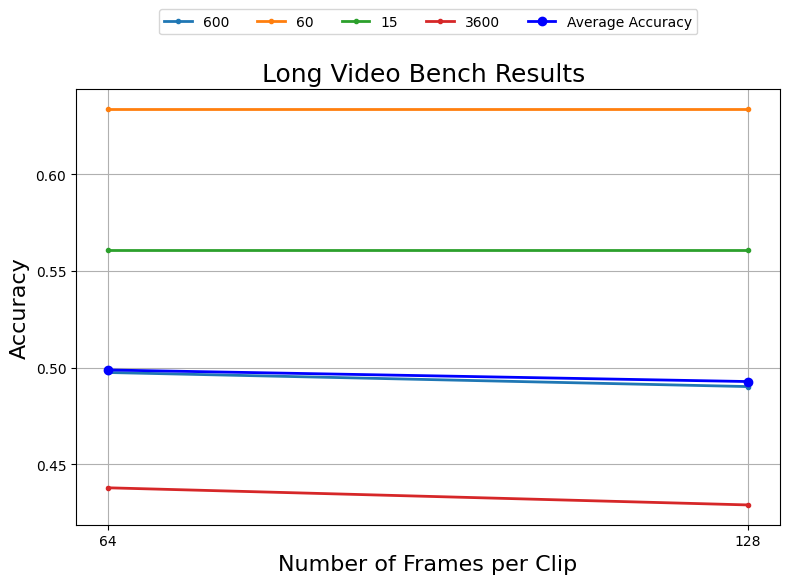

In [4]:
# Plot accuracy by window size

from matplotlib import pyplot as plt

def plot_window_results(results_dict, extra_title=""):

    accuracies = []
    windows = list(results_dict.keys())
    for window, results in results_dict.items():
        acc = calculate_accuracy(results)
        print(f"Window {window}: Accuracy = {acc:.4f}")
        accuracies.append(acc)
        
    # Calculate accuracy by duration group in data_entry field per window size

    duration_group_accuracies_window = {}
    for window, results in results_dict.items():
        duration_groups = {}
        duration_group_accuracies = {}
        for result in results:
            data_entry = result["data_entry"]
            duration_group = data_entry["metadata"]["duration_group"]
            if duration_group not in duration_groups:
                duration_groups[duration_group] = [result]
            else:   
                duration_groups[duration_group].append(result)
        
        for duration_group, result_duration_group in duration_groups.items():
            acc = calculate_accuracy(result_duration_group)
            duration_group_accuracies[duration_group] = acc
        
        duration_group_accuracies_window[window] = duration_group_accuracies


    # Structure the data as [duration_group, [accuracies]]
    plot_duration_group_accuracies = {
        duration_group: [[],[]] for duration_group in duration_group_accuracies_window[list(duration_group_accuracies_window.keys())[0]].keys()
    }
    for duration_group in duration_group_accuracies_window[list(duration_group_accuracies_window.keys())[0]].keys():
        for window in duration_group_accuracies_window.keys():
            plot_duration_group_accuracies[duration_group][0].append(window)
            plot_duration_group_accuracies[duration_group][1].append(duration_group_accuracies_window[window][duration_group])

    # Plot a line plot for all the average accuracies and the accuracies for each duration group (with correct legend)

    # Put the x axis in log scale

    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    ax.set_xscale('log', base=2)
    ax.set_xticks(sorted(windows))
    ax.set_xticklabels([str(w) for w in sorted(windows)])
    # I want different colors for each duration group
    colors = plt.cm.tab10.colors
    for i, duration_group in enumerate(plot_duration_group_accuracies.keys()):
        plt.plot(plot_duration_group_accuracies[duration_group][0], plot_duration_group_accuracies[duration_group][1], marker='.', linestyle='-', color=colors[i], linewidth=2, label=f'{duration_group}')
    plt.plot(windows, accuracies, marker='o', linestyle='-', color='b', linewidth=2, label='Average Accuracy')
    # for duration_group in plot_duration_group_accuracies.keys():
    #     plt.plot(plot_duration_group_accuracies[duration_group][0], plot_duration_group_accuracies[duration_group][1], marker='o', linestyle='-', color='r', label=f'Duration Group {duration_group}')
    plt.xlabel('Number of Frames per Clip', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.title(f'Long Video Bench Results {extra_title}', fontsize=18)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=len(labels))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_window_results(result_dict)

In [5]:
# Top K Test

topk_mapping = {
    1: 'topktest1',
    2: 'topktest2',
    4: 'topktest4',
    8: 'topktest8',
}

dataset_name = "lvb"
windows = [8,10,16,32]
result_dict_topk = {}
for k in topk_mapping.keys():
    if k == 1:
        continue
    result_paths = [f"../../results/{topk_mapping[k]}/{dataset_name}_{window}/agent_results.json" for window in windows]
    print(result_paths)
    result_dict_topk[k] = {}
    for result_path in result_paths:
        window = int(result_path.split("_")[1].split("/")[0])
        if not os.path.exists(result_path):
            continue
        with open(result_path, "r") as f:
            results = json.load(f)
            unanswered = 0
        for r in results:
            if r['parsed_pred'] == '':
                unanswered += 1
    
        print(f"Unanswered: {unanswered}")
        for result in results:
            result["data_entry"] = data_entries[result["question_id"]]
        result_dict_topk[k][window] = results
        


['../../results/topktest2/lvb_8/agent_results.json', '../../results/topktest2/lvb_10/agent_results.json', '../../results/topktest2/lvb_16/agent_results.json', '../../results/topktest2/lvb_32/agent_results.json']
Unanswered: 549
Unanswered: 549
Unanswered: 557
Unanswered: 575
['../../results/topktest4/lvb_8/agent_results.json', '../../results/topktest4/lvb_10/agent_results.json', '../../results/topktest4/lvb_16/agent_results.json', '../../results/topktest4/lvb_32/agent_results.json']
Unanswered: 575
Unanswered: 547
Unanswered: 599
Unanswered: 600
['../../results/topktest8/lvb_8/agent_results.json', '../../results/topktest8/lvb_10/agent_results.json', '../../results/topktest8/lvb_16/agent_results.json', '../../results/topktest8/lvb_32/agent_results.json']
Unanswered: 582
Unanswered: 575
Unanswered: 593
Unanswered: 619


In [6]:
def plot_topk_results(result_dict_topk, extra_title="Average Accuracy"):


    plt.figure(figsize=(8, 6))
    ax = plt.gca()
   

    for k in result_dict_topk.keys():
        results_dict = result_dict_topk[k]
        windows = list(results_dict.keys())
        ax.set_xscale('log', base=2)
        ax.set_xticks(sorted(windows))
        ax.set_xticklabels([str(w) for w in sorted(windows)])
        accuracies = []
        for window, results in results_dict.items():
            acc = calculate_accuracy(results)
            print(f"Window {window}: Accuracy = {acc:.4f}")
            accuracies.append(acc)
        

        # I want different colors for each duration group
        colors = plt.cm.tab10.colors
        plt.plot(windows, accuracies, marker='o', linestyle='-', color=colors[k], linewidth=2, label=f'Top {k} Results')
        # for duration_group in plot_duration_group_accuracies.keys():
        #     plt.plot(plot_duration_group_accuracies[duration_group][0], plot_duration_group_accuracies[duration_group][1], marker='o', linestyle='-', color='r', label=f'Duration Group {duration_group}')
    plt.xlabel('Number of Frames per Clip', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.title(f'Long Video Bench Results {extra_title}', fontsize=18)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=len(labels))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Window 8: Accuracy = 0.2423
Window 10: Accuracy = 0.2334
Window 16: Accuracy = 0.2401
Window 32: Accuracy = 0.2199


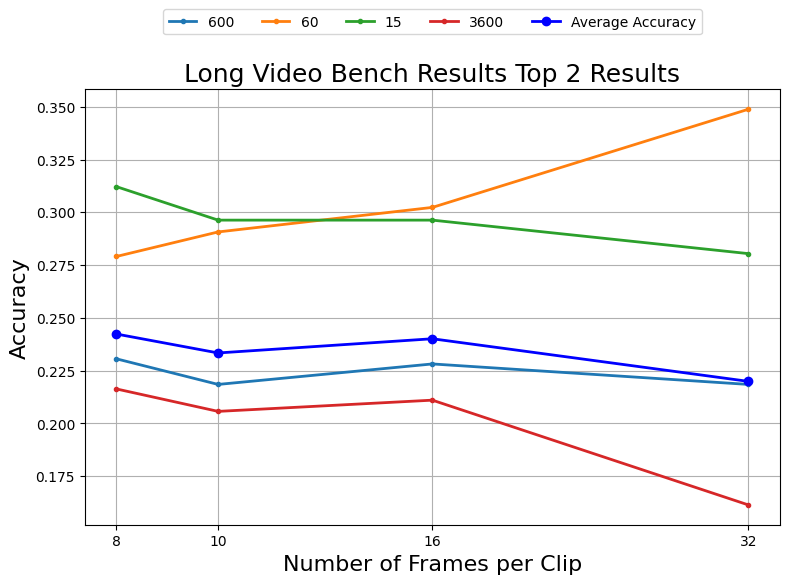

Window 8: Accuracy = 0.2311
Window 10: Accuracy = 0.2326
Window 16: Accuracy = 0.2064
Window 32: Accuracy = 0.2004


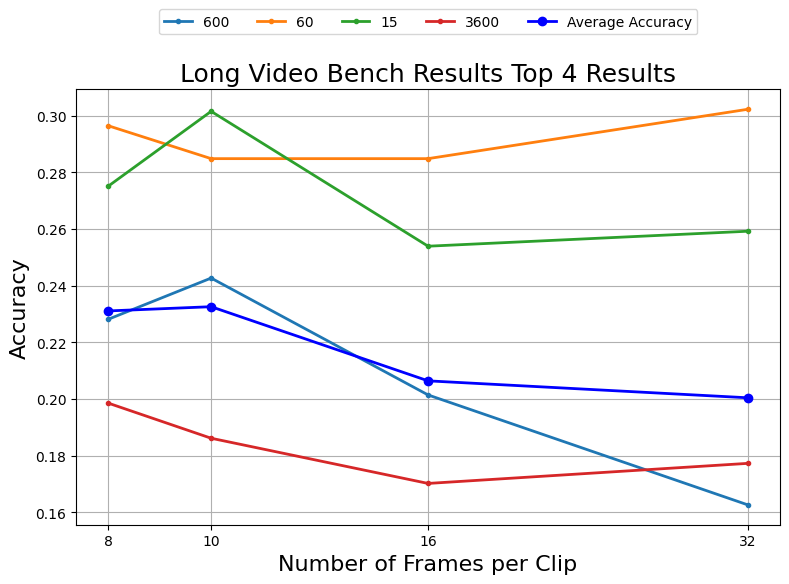

Window 8: Accuracy = 0.2438
Window 10: Accuracy = 0.2191
Window 16: Accuracy = 0.2169
Window 32: Accuracy = 0.2042


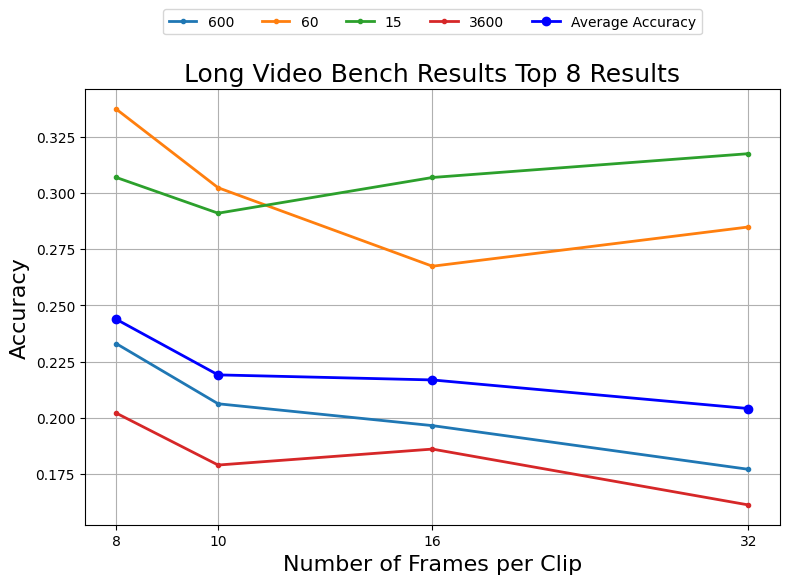

In [7]:
for k in result_dict_topk.keys():
    plot_window_results(result_dict_topk[k], extra_title=f"Top {k} Results")




Window 8: Accuracy = 0.2423
Window 10: Accuracy = 0.2334
Window 16: Accuracy = 0.2401
Window 32: Accuracy = 0.2199
Window 8: Accuracy = 0.2311
Window 10: Accuracy = 0.2326
Window 16: Accuracy = 0.2064
Window 32: Accuracy = 0.2004
Window 8: Accuracy = 0.2438
Window 10: Accuracy = 0.2191
Window 16: Accuracy = 0.2169
Window 32: Accuracy = 0.2042


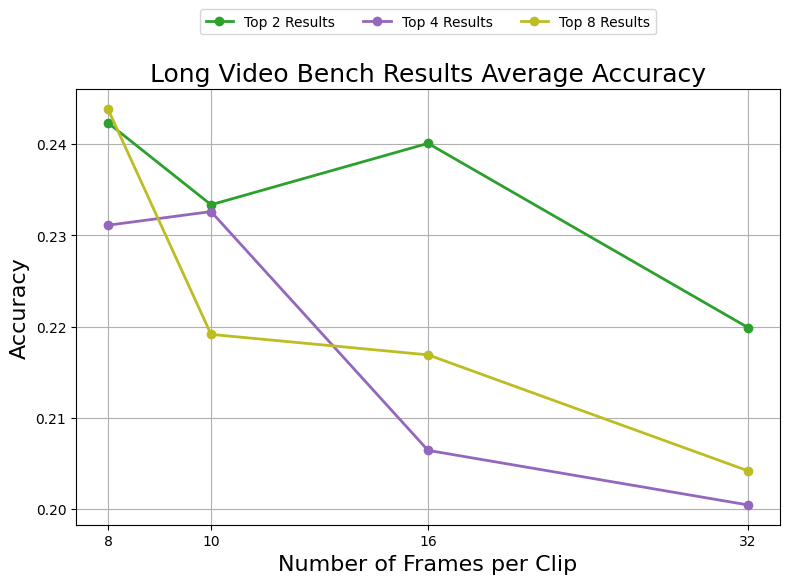

In [8]:
plot_topk_results(result_dict_topk)